In [1]:
# Integrated Explainable AI Framework for Bias Detection, Fairness Evaluation, and Mitigation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #split data into training and testing set
from sklearn.preprocessing import StandardScaler, LabelEncoder #normalization and convert text labels to numbers
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix #measure performance and helps calculate fairness metrix
import warnings

# Install SHAP
try:
    import shap
except ImportError:
    import os
    os.system('pip install shap')
    import shap

warnings.filterwarnings('ignore')

--- Steps 1 & 2: Loading and Preprocessing ---


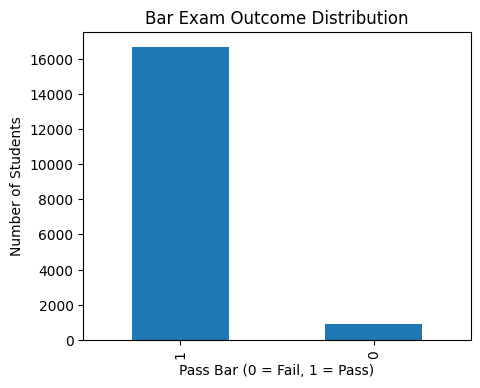

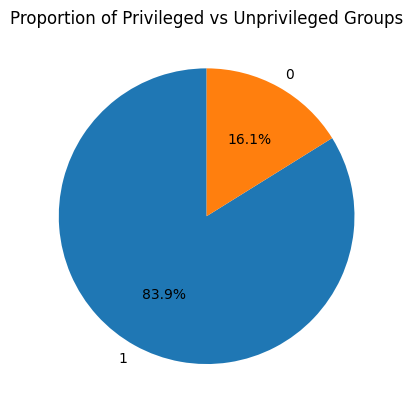

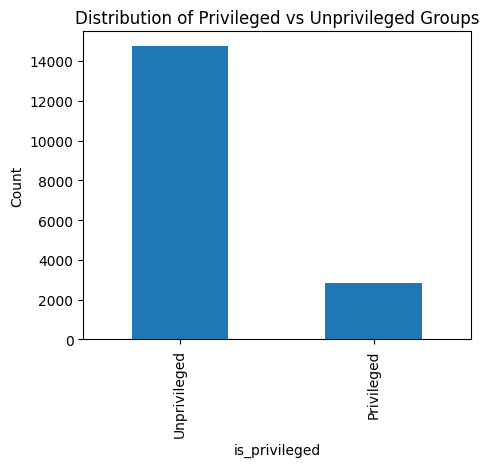

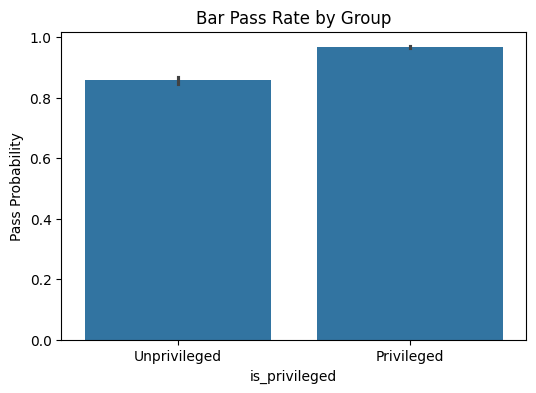

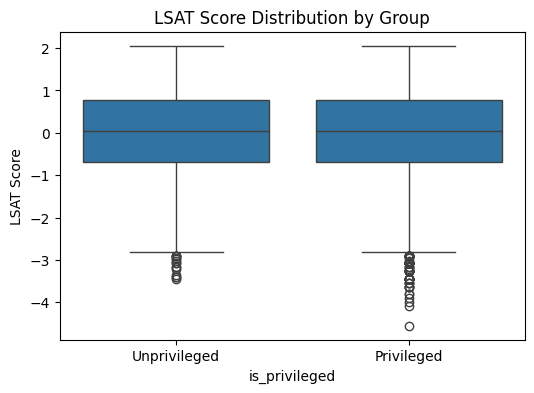

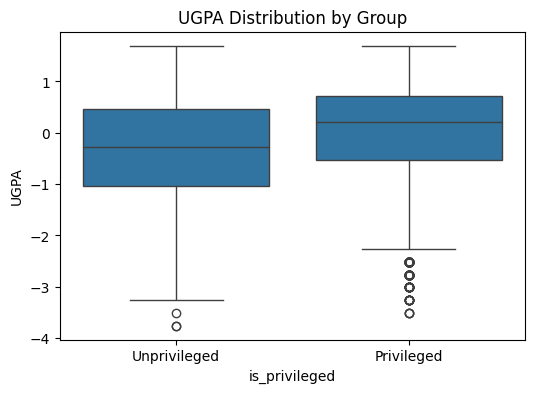

In [2]:
# ---------------------------------------------------------
# STEP 1 & 2: Dataset Selection and Preprocessing
# ---------------------------------------------------------
def prepare_data(file_path):
    print("--- Steps 1 & 2: Loading and Preprocessing ---")
    df = pd.read_csv('https://raw.githubusercontent.com/ShaziyaJabeen28/AI_Bias_Detection/refs/heads/main/Datasets/bar_pass_prediction.csv')
    df
    # Selecting target and features relevant to fairness research
    # Target: 'pass_bar'
    # Sensitive Features: 'race1', 'male'

    target = 'pass_bar'  #exam outcome
    features = ['lsat', 'ugpa', 'fulltime', 'fam_inc', 'age', 'male', 'race1']

    #remove missing values
    df = df[features + [target]].dropna()

    # Label Encoding for categorical sensitive attribute
    le = LabelEncoder()
    df['race1_encoded'] = le.fit_transform(df['race1'])

    # Define Privileged (White) vs Unprivileged (All others)
    # We identify the 'white' label index
    white_idx = np.where(le.classes_ == 'white')[0][0]
    df['is_privileged'] = (df['race1_encoded'] == white_idx).astype(int)

#Removes sensitive attributes from fratures, Prevents direct discrimination
    X = df.drop([target, 'race1', 'race1_encoded'], axis=1)
    y = df[target]

    # Scaling is crucial for SVM and Logistic Regression
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    return train_test_split(X_scaled, y, df['is_privileged'], test_size=0.2, random_state=42), le

(X_train, X_test, y_train, y_test, priv_train, priv_test), race_encoder = prepare_data('bar_pass_prediction.csv')

#Class Distribution (Pass vs Fail)
plt.figure(figsize=(5,4))
y_train.value_counts().plot(kind='bar')
plt.title('Bar Exam Outcome Distribution')
plt.xlabel('Pass Bar (0 = Fail, 1 = Pass)')
plt.ylabel('Number of Students')
plt.show()

print("\n")

#UGPA Distribution by Group
priv_train.value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Proportion of Privileged vs Unprivileged Groups')
plt.ylabel('')
plt.show()

print("\n")

#Pass Rate by Race (Key Fairness Insight)
plt.figure(figsize=(5,4))
priv_train.value_counts().plot(kind='bar')
plt.xticks([0,1], ['Unprivileged', 'Privileged'])
plt.title('Distribution of Privileged vs Unprivileged Groups')
plt.ylabel('Count')
plt.show()

print("\n")

#Class Distribution (Pass vs Fail)
df_plot = pd.DataFrame({
    'pass_bar': y_train,
    'is_privileged': priv_train
})

plt.figure(figsize=(6,4))
sns.barplot(x='is_privileged', y='pass_bar', data=df_plot)
plt.xticks([0,1], ['Unprivileged', 'Privileged'])
plt.title('Bar Pass Rate by Group')
plt.ylabel('Pass Probability')
plt.show()

print("\n")

#Feature Distribution by Group
plt.figure(figsize=(6,4))
sns.boxplot(x=priv_train, y=X_train['lsat'])
plt.xticks([0,1], ['Unprivileged', 'Privileged'])
plt.title('LSAT Score Distribution by Group')
plt.ylabel('LSAT Score')
plt.show()

print("\n")

#UGPA Distribution by Group
plt.figure(figsize=(6,4))
sns.boxplot(x=priv_train, y=X_train['ugpa'])
plt.xticks([0,1], ['Unprivileged', 'Privileged'])
plt.title('UGPA Distribution by Group')
plt.ylabel('UGPA')
plt.show()



--- Step 3: Training & Finding Best Model ---
Logistic Regression Accuracy: 0.9475
Random Forest Accuracy: 0.9457
SVM Accuracy: 0.9463


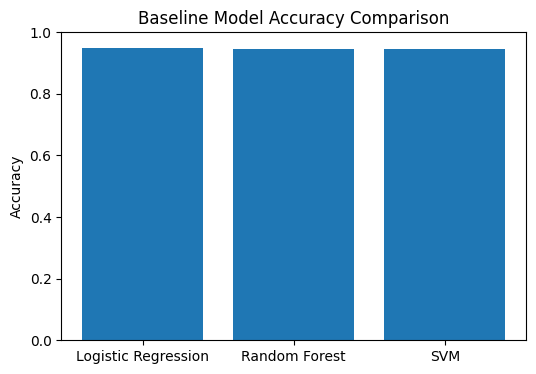


Result: Logistic Regression is the best model.


In [3]:
# ---------------------------------------------------------
# STEP 3: Baseline Model Training & Comparison
# ---------------------------------------------------------
print("\n--- Step 3: Training & Finding Best Model ---")
model_candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', C=1.0)
}

#best model selection
best_acc = 0
best_model = None
best_model_name = ""

for name, clf in model_candidates.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_model = clf
        best_model_name = name

# Accuracy Comparison Plot
plt.figure(figsize=(6,4))
plt.bar(model_candidates.keys(),
        [results := [
            accuracy_score(y_test, model_candidates[m].predict(X_test))
            for m in model_candidates
        ]][0])

plt.title('Baseline Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()


print(f"\nResult: {best_model_name} is the best model.")




--- Step 4 & 5: Bias Detection Results ---
Demographic Parity Difference: 0.0251 (Lower is better)
Equal Opportunity Difference: 0.0109 (Lower is better)




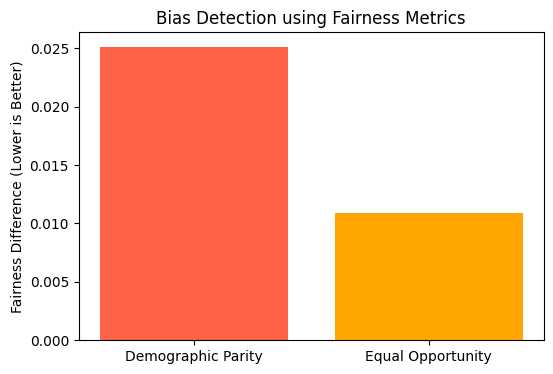

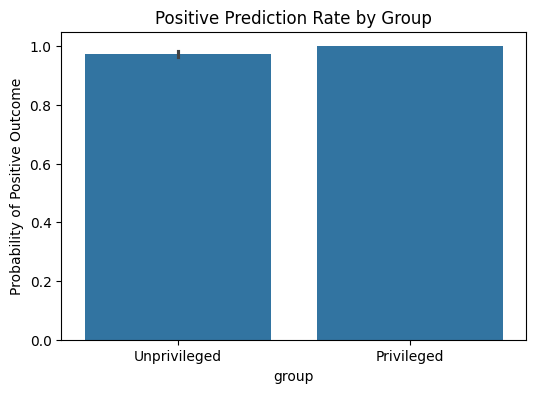

In [4]:
# ---------------------------------------------------------
# STEP 4 & 5: Bias Detection & Analysis
# ---------------------------------------------------------
def get_fairness_metrics(y_true, y_pred, priv_attr):
    # Split predictions by group
    y_priv = y_pred[priv_attr == 1]
    y_unpriv = y_pred[priv_attr == 0]

    # 1. Demographic Parity (Difference in positive prediction rates)
    dp_diff = np.abs(y_priv.mean() - y_unpriv.mean())

    # 2. Equal Opportunity (Difference in True Positive Rates)
    cm_priv = confusion_matrix(y_true[priv_attr == 1], y_priv, normalize='true')
    cm_unpriv = confusion_matrix(y_true[priv_attr == 0], y_unpriv, normalize='true')

    tpr_priv = cm_priv[1, 1] if len(cm_priv) > 1 else 0
    tpr_unpriv = cm_unpriv[1, 1] if len(cm_unpriv) > 1 else 0
    eop_diff = np.abs(tpr_priv - tpr_unpriv)

    return {"Demographic Parity": dp_diff, "Equal Opportunity": eop_diff}

baseline_preds = best_model.predict(X_test)
baseline_fairness = get_fairness_metrics(y_test, baseline_preds, priv_test)

print("\n--- Step 4 & 5: Bias Detection Results ---")
for k, v in baseline_fairness.items():
    print(f"{k} Difference: {v:.4f} (Lower is better)")

print("\n")
# Plot Fairness Metrics
plt.figure(figsize=(6,4))
plt.bar(baseline_fairness.keys(), baseline_fairness.values(), color=['tomato', 'orange'])
plt.title('Bias Detection using Fairness Metrics')
plt.ylabel('Fairness Difference (Lower is Better)')
plt.show()

print("\n")

# Prediction rate comparison
df_bias = pd.DataFrame({
    'prediction': baseline_preds,
    'group': priv_test
})

plt.figure(figsize=(6,4))
sns.barplot(x='group', y='prediction', data=df_bias)
plt.xticks([0,1], ['Unprivileged', 'Privileged'])
plt.title('Positive Prediction Rate by Group')
plt.ylabel('Probability of Positive Outcome')
plt.show()




--- Step 6 & 7: Explainable AI Analysis ---


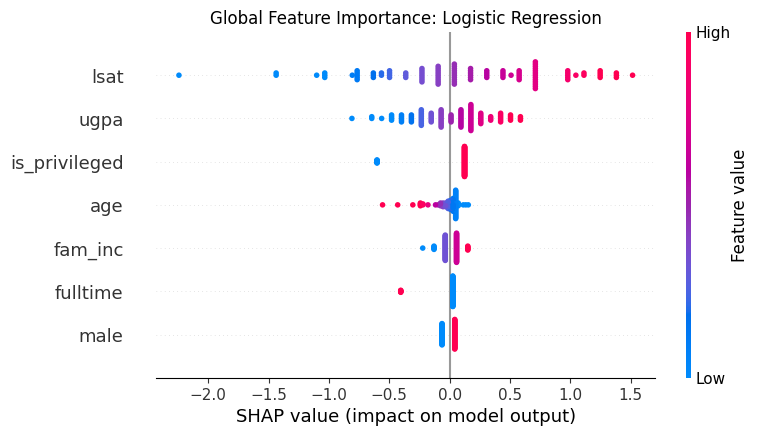

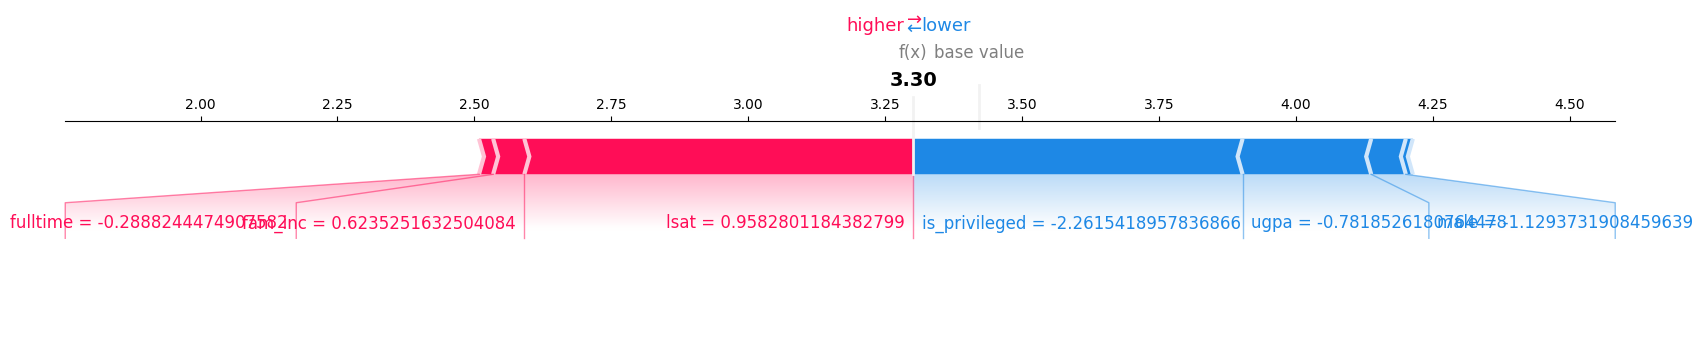

In [5]:
# ---------------------------------------------------------
# STEP 6 & 7: XAI Analysis (SHAP)
# ---------------------------------------------------------
print("\n--- Step 6 & 7: Explainable AI Analysis ---")
# Use KernelExplainer for SVM/LR or TreeExplainer for RF
X_sample = X_test.iloc[:100] # Subset for speed

if "Random Forest" in best_model_name:
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(X_sample)
    # Binary class: take class 1
    shap_vals_plot = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
elif "Logistic Regression" in best_model_name:
    explainer = shap.LinearExplainer(best_model, X_train, feature_perturbation="interventional")
    shap_vals_plot = explainer.shap_values(X_sample)
else: # SVM
    # SVM requires background data summary
    background = shap.kmeans(X_train, 10)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_vals_plot = explainer.shap_values(X_sample)[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_plot, X_sample, show=False)
plt.title(f"Global Feature Importance: {best_model_name}")
plt.show()

print("\t")

# Individual explanation
shap.force_plot(
    explainer.expected_value,
    shap_vals_plot[0],
    X_sample.iloc[0],
    matplotlib=True
)


In [6]:
# ---------------------------------------------------------
# STEP 8: Bias Mitigation (Post-processing)
# ---------------------------------------------------------
print("\n--- Step 8: Bias Mitigation (Threshold Adjustment) ---")
# We reduce the threshold for the unprivileged group to balance TPR
probs = best_model.predict_proba(X_test)[:, 1]
mitigated_preds = np.zeros_like(probs)

# Standard threshold for privileged, lowered for unprivileged
mitigated_preds[(priv_test == 1) & (probs >= 0.50)] = 1
mitigated_preds[(priv_test == 0) & (probs >= 0.35)] = 1



--- Step 8: Bias Mitigation (Threshold Adjustment) ---



--- Step 9: Comparison & Final Evaluation ---


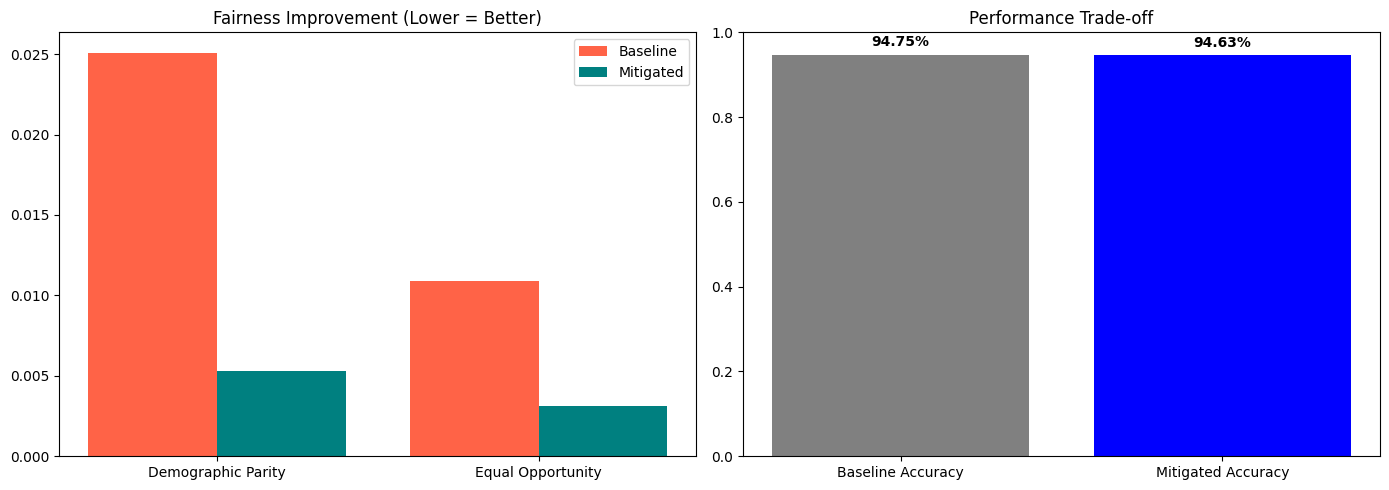


Framework Summary for Logistic Regression:
Fairness Improvement (DP): 78.95% reduction in bias.
Final Mitigated Accuracy: 94.63%


In [7]:
# ---------------------------------------------------------
# STEP 9: Post-Mitigation Evaluation
# ---------------------------------------------------------
print("\n--- Step 9: Comparison & Final Evaluation ---")
mitigated_fairness = get_fairness_metrics(y_test, mitigated_preds, priv_test)
mitigated_acc = accuracy_score(y_test, mitigated_preds)

# Visualization
metrics = list(baseline_fairness.keys())
before = [baseline_fairness[m] for m in metrics]
after = [mitigated_fairness[m] for m in metrics]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Fairness
x = np.arange(len(metrics))
ax[0].bar(x - 0.2, before, 0.4, label='Baseline', color='tomato')
ax[0].bar(x + 0.2, after, 0.4, label='Mitigated', color='teal')
ax[0].set_xticks(x)
ax[0].set_xticklabels(metrics)
ax[0].set_title('Fairness Improvement (Lower = Better)')
ax[0].legend()

# Plot Accuracy
ax[1].bar(['Baseline Accuracy', 'Mitigated Accuracy'], [best_acc, mitigated_acc], color=['gray', 'blue'])
ax[1].set_ylim(0, 1)
ax[1].set_title('Performance Trade-off')
for i, v in enumerate([best_acc, mitigated_acc]):
    ax[1].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFramework Summary for {best_model_name}:")
print(f"Fairness Improvement (DP): {((before[0]-after[0])/before[0]):.2%} reduction in bias.")
print(f"Final Mitigated Accuracy: {mitigated_acc:.2%}")

In [8]:
# ---------------------------------------------------------
# STEP 10: Create Integrated Dataset
# ---------------------------------------------------------
print("\n--- Step 10: Creating Integrated Dataset ---")

integrated_df = X_test.copy()

# Add ground truth
integrated_df['actual_pass'] = y_test.values

# Add predictions
integrated_df['baseline_prediction'] = baseline_preds
integrated_df['mitigated_prediction'] = mitigated_preds

# Add group info
integrated_df['is_privileged'] = priv_test.values

# Add fairness metrics (global – repeated for reference)
integrated_df['demographic_parity_diff'] = baseline_fairness['Demographic Parity']
integrated_df['equal_opportunity_diff'] = baseline_fairness['Equal Opportunity']

# Add SHAP values (optional but powerful)
shap_df = pd.DataFrame(
    shap_vals_plot,
    columns=X_sample.columns
)

integrated_df = integrated_df.iloc[:len(shap_df)].reset_index(drop=True)
integrated_df = pd.concat([integrated_df, shap_df.add_prefix('shap_')], axis=1)

# Save integrated dataset
integrated_df.to_csv("integrated_explainable_fairness_dataset.csv", index=False)

print("Integrated dataset created and saved successfully.")


--- Step 10: Creating Integrated Dataset ---
Integrated dataset created and saved successfully.


In [9]:
integrated_df.head()

,lsat,ugpa,fulltime,fam_inc,age,male,is_privileged,actual_pass,baseline_prediction,mitigated_prediction,demographic_parity_diff,equal_opportunity_diff,shap_lsat,shap_ugpa,shap_fulltime,shap_fam_inc,shap_age,shap_male,shap_is_privileged
0,0.958280,-0.781853,-0.288824,0.623525,0.014086,-1.129373,0,1,1,1.0,0.025099,0.010886,0.709923,-0.234839,0.025866,0.056944,-0.012742,-0.063289,-0.601734
1,-0.143678,0.209662,3.462311,-2.879602,-0.173859,0.885447,1,1,1,1.0,0.025099,0.010886,-0.095283,0.093607,-0.405240,-0.223107,0.008147,0.042193,0.123247
2,-0.878316,0.209662,-0.288824,0.623525,0.014086,-1.129373,1,1,1,1.0,0.025099,0.010886,-0.632087,0.093607,0.025866,0.056944,-0.012742,-0.063289,0.123247
3,0.223642,0.457541,-0.288824,-0.544184,0.389977,0.885447,1,1,1,1.0,0.025099,0.010886,0.173119,0.175719,0.025866,-0.036407,-0.054521,0.042193,0.123247
4,-0.694657,-0.533974,-0.288824,0.623525,2.645320,-1.129373,1,1,1,1.0,0.025099,0.010886,-0.497886,-0.152728,0.025866,0.056944,-0.305193,-0.063289,0.123247


In [10]:
integrated_df.shape


(100, 19)

In [11]:
integrated_df.columns

Index(['lsat', 'ugpa', 'fulltime', 'fam_inc', 'age', 'male', 'is_privileged',
       'actual_pass', 'baseline_prediction', 'mitigated_prediction',
       'demographic_parity_diff', 'equal_opportunity_diff', 'shap_lsat',
       'shap_ugpa', 'shap_fulltime', 'shap_fam_inc', 'shap_age', 'shap_male',
       'shap_is_privileged'],
      dtype='object')